In [1]:
import math
import numpy as np
import random
import time
import matplotlib.pyplot as plt
from collections import defaultdict
from matplotlib.patches import Ellipse
from itertools import chain
import time
from operator import attrgetter

In [2]:
def surface_single(x, U, A, p=2):
    """
    Compute the hyperellipsoid surface function for a single point.

    Parameters
    ----------
    x : np.ndarray, shape (d,)
        The query point.
    U : np.ndarray, shape (d, d)
        Eigenvectors (columns) defining the ellipsoid orientation.
    A : np.ndarray, shape (d,)
        Semi-axis lengths along each eigenvector direction.

    Returns
    -------
    float
        < 0 if x is inside the ellipsoid
        = 0 if x is on the surface
        > 0 if x is outside the ellipsoid
    """
    x_local = U.T @ x        # Project into ellipsoid's local frame, shape (d,)
    return np.sum(np.abs(x_local / A) ** p) - 1

In [3]:
def surface_multi(xs, Us, As, p=2):
    """
    Compute the hyperellipsoid surface function for n points,
    each against its own ellipsoid.

    Parameters
    ----------
    xs : np.ndarray, shape (n, d)
        Query points.
    Us : np.ndarray, shape (n, d, d)
        Per-ellipsoid eigenvector matrices.
    As : np.ndarray, shape (n, d)
        Per-ellipsoid semi-axis lengths.

    Returns
    -------
    np.ndarray, shape (n,)
        Surface function value for each (point, ellipsoid) pair.
        < 0 inside, = 0 on surface, > 0 outside.
    """
    xs_local = np.einsum('ndi, ni -> nd', Us.swapaxes(1,2), xs)  # (n, d)
    return np.sum(np.abs(xs_local / As) ** p, axis=1) - 1              # (n,)

In [4]:
def print_time(arr, name):
    print(f"action: {name}")
    print(f"count: {len(arr)}")
    print(f"total: {sum(arr)}")
    print(f"avg: {sum(arr)/len(arr)}")

In [5]:
def print_stat(arr, name):
    print(f"{name} Mean:", np.mean(arr))
    print(f"{name} Max:", np.max(arr))
    print(f"{name} Min:", np.min(arr))

In [6]:
def merge_nodes(x, y):
    new_n = x.n + y.n
    dist = x.M - y.M
    new_M = ((x.n * x.M) + (y.n * y.M)) / (new_n)
    new_S = ((x.n / new_n) * x.S) + ((y.n / new_n) * y.S) + (((x.n * y.n)/ (new_n ** 2)) * (np.outer(dist, dist)))
    eigen_value, eigen_vector = np.linalg.eigh(new_S)
    # reverse the order of the eigenvalue/vectors to be in DESCENDING order
    eigen_value = eigen_value[::-1]
    eigen_vector = eigen_vector[:, ::-1]
    # eigen_vector = eigen_vector.T
    new_A = np.sqrt(np.pi * 2 * np.abs(eigen_value))
    new_A[new_A == 0] = x.eps

    return Node(dimension=x.dim, label=x.label, A=new_A, n=new_n, M=new_M, S=new_S, U=eigen_vector, eps=x.eps, default_width=x.default_width, alpha=x.alpha)

In [7]:
class Node():
    def __init__(self, dimension, label, A=None, n=1, M=None, S=None, U=None, eps=0.00001, default_width=1., alpha=0.55):
        default_A = np.array([default_width] * dimension, dtype=float)
        self.default_width = default_width
        default_U = np.eye(dimension)
        self.dim = dimension
        self.label = label
        self.eps = eps
        self.n = n
        self.alpha = alpha
        self.U = default_U if U is None else U
        self.M = np.array([0.] * dimension) if M is None else M
        self.S = np.zeros((dimension, dimension)) if S is None else S
        self.A = default_A if A is None else A

    def update(self, x, parent):

        # Calculate new mean and cov matrix
        n = self.n
        M = self.M
        alpha = n / (n + 1)
        beta = x / (n + 1)
        M_new = (alpha * M) + beta
        k_1 = (np.outer(x, x)/(n + 1)) - np.outer(M_new, M_new) + np.outer(M, M)
        k_2 = - (np.outer(M, M) / (n + 1))
        k = k_1 + k_2
        S_new = (alpha * self.S) + k

        eigen_value, eigen_vector = np.linalg.eigh(S_new)
        # reverse the order of the eigenvalue/vectors to be in DESCENDING order
        eigen_value = eigen_value[::-1]
        eigen_vector = eigen_vector[:, ::-1]

        # calculate new width with adaptively by combining fixed and dynamic width update rules
        beta = 1 - self.alpha
        fixed = np.sqrt(np.pi * 2 * np.abs(eigen_value))
        dynamic = self.A + ((M_new - self.M) @ eigen_vector)
        new_A = (self.alpha * fixed) + (beta * dynamic)
        new_A[new_A == 0] = self.eps
        
        gc = surface_single(x - M_new, eigen_vector, self.A)
        if gc <= 0:
            # update the current node
            self.M = M_new
            self.U = eigen_vector
            self.S = S_new
            self.A = new_A
            self.n += 1
            return self
        else:
            # add new node
            new_node = Node(self.dim, self.label, M=x, eps=self.eps, default_width=self.default_width, alpha=self.alpha)
            parent.nodes[self.label].append(new_node)
            return new_node

    def __str__(self):
        return f"A node covering {self.n} points."

In [15]:
class VEBF():
    def __init__(self, dimension, merge_parameter, eps=0.00001, default_width=1., alpha=0.55):
        self.dim = dimension
        self.merge_parameter = merge_parameter
        self.nodes = {}
        self.eps = eps
        self.alpha = alpha
        self.default_width = default_width

    def find_shortest(self, x, y):
        # TODO: vectorize this
        min_dist = float('inf')
        min_node = None
        for node in self.nodes[y]:
            dist = np.linalg.norm(node.M - x)
            if dist < min_dist:
                min_dist = dist
                min_node = node
        return min_node

    # NOTE: can combine this with find_shortest by using y=None as default value
    def find_shortest_all(self, x, nodes=None):
        min_dist = float('inf')
        min_node = None
        nodes = self.get_nodes() if nodes is None else nodes
        for node in nodes:
            dist = np.linalg.norm(node.M - x)
            if dist < min_dist:
                min_dist = dist
                min_node = node
        return min_node

    def check_merge(self, x):
        """
        Check for pair of nodes which can be merged.
        Only consider the "latest" node x

        Parameters:
        x (Node): The node which has just been updated or created.
        """
        nodes = self.nodes[x.label]
        if len(nodes) == 1:
            return
        nodes.remove(x)

        Us = np.array([node.U for node in nodes])
        Ms = np.array([node.M for node in nodes])
        As = np.array([node.A for node in nodes])
        
        scores = surface_multi(x.M - Ms, Us, As)
        merge_candidates = [node for node, score in zip(nodes, scores) if score <= self.merge_parameter]
        if len(merge_candidates) > 0:
            y = merge_candidates[0]
            nodes.remove(y)
            new_node = merge_nodes(x, y)
            nodes.append(new_node)
            self.check_merge(new_node)
            return

        n = len(nodes)
        U = x.U
        A = x.A
        Us = np.broadcast_to(U, (n,) + U.shape)
        As = np.broadcast_to(A, (n,) + A.shape)

        scores = surface_multi(Ms - x.M, Us, As)
        merge_candidates = [node for node, score in zip(nodes, scores) if score <= self.merge_parameter]
        if len(merge_candidates) > 0:
            y = merge_candidates[0]
            nodes.remove(y)
            new_node = merge_nodes(y, x)
            nodes.append(new_node)
            self.check_merge(new_node)
            return
            
        nodes.append(x)

    def get_nodes(self):
        return list(chain.from_iterable(self.nodes.values()))

    def predict(self, x):

        nodes = self.get_nodes()
        Us = np.array([node.U for node in nodes])
        Ms = np.array([node.M for node in nodes])
        As = np.array([node.A for node in nodes])

        scores = surface_multi(x - Ms, Us, As)
        candidates = [node for node, score in zip(nodes, scores) if score <= 0]

        if len(candidates) == 0:
            closest = self.find_shortest_all(x)
            return closest.label
        return self.find_shortest_all(x, candidates).label
            
    def train(self, x, y):
        if y not in self.nodes: # Add a new node for unseen label.
            self.nodes[y] = [Node(dimension=self.dim, label=y, M=x, eps=self.eps, default_width=self.default_width, alpha=self.alpha)]
        else: # Update closest existing node for existing label.
            shortest = self.find_shortest(x, y)
            latest = shortest.update(x, self) # latest is the node with latest change, which need to checked for merge
            self.check_merge(latest)

    def __str__(self):
        total = sum(len(x) for x in self.nodes.values())
        string = f"A vebf with {total} nodes.\n"
        for label, nodes in self.nodes.items():
            for node in nodes:
                string += f"Label {label}: {str(node)}\n"
        return string

In [9]:
def train_test_split(ds, test_ratio=0.2):
    ds = ds[:]  # copy
    random.shuffle(ds)

    split_idx = int(len(ds) * (1 - test_ratio))
    return ds[:split_idx], ds[split_idx:]

def visualize_pair(ds, vebf, name, var_name, i, j, save=False):

    fig, ax = plt.subplots()

    # seperate the points by class label
    classes = defaultdict(list)
    for point, label in ds:
        classes[label].append(point[[i, j]])
        
    # plot the datapoints
    for label, points in classes.items():
        points = np.array(points)
        ax.scatter(points[:, 0], points[:, 1], label=f"{label}")

    
    # plot the ellipses
    for label, nodes in vebf.nodes.items():
        for node in nodes:
            c = node.M[[i, j]]
            l1,l2 = node.A[:2] * 2
            u1,u2 = node.U[:2]
            u1,u2 = u1[[i, j]], u2[[i, j]]
            angle = np.degrees(np.arctan2(u1[1] * l1, u1[0] * l1))
            ax.add_patch(Ellipse(xy=c, width=l1, height=l2, angle=angle, fill=False))
    
    # plt.legend()
    # plt.xlabel("X1")
    # plt.ylabel("X2")
    ax.set_aspect('equal')
    plt.title(name)
    plt.xlabel(var_name[i])
    plt.ylabel(var_name[j])
    #plt.xlim(left=0,)
    #plt.ylim(bottom=0)
    plt.axis('equal')
    if save:
        plt.savefig(name + ".png")
    plt.show()

def visualize_all(ds, vebf, variable_name, plot_name, save=False):
    i = 0
    d = vebf.dim
    while i < d:
        for j in range(i + 1, d):
            x1 = str(variable_name[i])
            x2 = str(variable_name[j])
            visualize_pair(ds, vebf, " ".join([plot_name,x1,x2]), variable_name, i, j, save)
        i += 1

In [11]:
with open("data/iris/iris.data", "r") as f:
    iris_data = f.readlines()
iris_ds = []
for line in iris_data[:-1]:
    line = line.strip().split(',')
    x = np.array(line[:-1], dtype=float)
    y = line[-1]
    iris_ds.append((x, y))

with open("data/ecoli/ecoli.data", "r") as f:
    ecoli_data = f.readlines()
ecoli_ds = []
for line in ecoli_data:
    line = line.strip().split()
    x = np.array(line[1:-1], dtype=float)
    y = line[-1]
    ecoli_ds.append((x, y))

with open("data/image_seg/segmentation.data", "r") as f:
    seg_train_data = f.readlines()
with open("data/image_seg/segmentation.test", "r") as f:
    seg_test_data = f.readlines()
seg_train = []
for line in seg_train_data[5:]:
    line = line.strip().split(",")
    y = line[0]
    x = np.array(line[1:], dtype=float)
    seg_train.append((x, y))
seg_test = []
for line in seg_test_data[5:]:
    line = line.strip().split(",")
    y = line[0]
    x = np.array(line[1:], dtype=float)
    seg_test.append((x, y))

with open("data/waveform/waveform.data", "r") as f:
    waveform_data = f.readlines()
waveform_ds = []
for line in waveform_data:
    line = line.strip().split(",")
    y = line[-1]
    x = np.array(line[:-1], dtype=float)
    waveform_ds.append((x, y))

with open("data/yeast/yeast.data", "r") as f:
    yeast_data = f.readlines()
yeast_ds = []
for line in yeast_data:
    line = line.strip().split()
    x = np.array(line[1:-1], dtype=float)
    y = line[-1]
    yeast_ds.append((x, y))

In [12]:
iris_A = 2.5
ecoli_A = 1.2
yeast_A = 0.75
wave_A = 9.69

# Shuffle Test/Train Split

In [16]:
iris_result = {}
for i in range(100):

    # shuffle the train/test split
    iris_train, iris_test = train_test_split(iris_ds)
    model = VEBF(dimension=4, merge_parameter=0., default_width=iris_A)
    for idx in range(len(iris_train)):
        x,y = iris_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in iris_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    iris_result[i] = {"acc": correct/len(iris_test)}

In [17]:
ecoli_result = {}
for i in range(30):

    # shuffle the order in which the data is presented
    ecoli_train, ecoli_test = train_test_split(ecoli_ds)
    model = VEBF(dimension=7, merge_parameter=0., default_width=ecoli_A)
    for idx in range(len(ecoli_train)):
        x,y = ecoli_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in ecoli_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    ecoli_result[i] = {"acc": correct/len(ecoli_test)}

In [18]:
yeast_result = {}
for i in range(30):

    # shuffle the order in which the data is presented
    yeast_train, yeast_test = train_test_split(yeast_ds)
    model = VEBF(dimension=8, merge_parameter=0., default_width=yeast_A)
    for idx in range(len(yeast_train)):
        x,y = yeast_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in yeast_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    yeast_result[i] = {"acc": correct/len(yeast_test)}

In [19]:
wave_result = {}
for i in range(1):

    # shuffle the order in which the data is presented
    wave_train, wave_test = train_test_split(waveform_ds)
    model = VEBF(dimension=21, merge_parameter=0., default_width=wave_A)
    for idx in range(len(wave_train)):
        x,y = wave_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in wave_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    wave_result[i] = {"acc": correct/len(wave_test)}

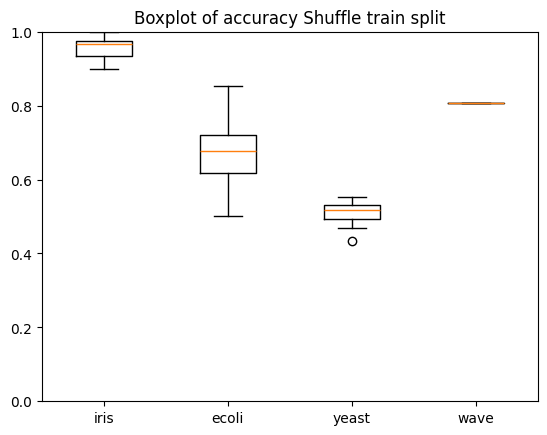

In [20]:
iris_acc = []
ecoli_acc = []
seg_acc = []
wave_acc = []
yeast_acc = []

for _, result in iris_result.items():
    iris_acc.append(result["acc"])
for _, result in ecoli_result.items():
    ecoli_acc.append(result["acc"])
for _, result in yeast_result.items():
    yeast_acc.append(result["acc"])
for _, result in wave_result.items():
    wave_acc.append(result["acc"])

plt.boxplot([iris_acc, ecoli_acc, yeast_acc, wave_acc])
plt.xticks([1, 2, 3, 4], ["iris", "ecoli", "yeast", "wave"])
plt.ylim(0, 1)
plt.title("Boxplot of accuracy Shuffle train split")
plt.show()

In [98]:
# testing
print_stat(iris_acc, "iris")
print()
print_stat(ecoli_acc, "ecoli")
print()
print_stat(yeast_acc, "yeast")
print()
print_stat(wave_acc, "wave")

iris Mean: 0.944
iris Max: 1.0
iris Min: 0.8

ecoli Mean: 0.8088235294117647
ecoli Max: 0.8823529411764706
ecoli Min: 0.75

yeast Mean: 0.4996632996632997
yeast Max: 0.5420875420875421
yeast Min: 0.43097643097643096

wave Mean: 0.781
wave Max: 0.781
wave Min: 0.781


# Shuffle Train Order

In [22]:
iris_idx = [i for i in range(len(iris_train))]
ecoli_idx = [i for i in range(len(ecoli_train))]
#seg_idx = [i for i in range(len(seg_train))]
wave_idx = [i for i in range(len(wave_train))]
yeast_idx = [i for i in range(len(yeast_train))]

In [24]:
iris_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    random.shuffle(iris_idx)
    model = VEBF(dimension=4, merge_parameter=0., default_width=iris_A)
    for idx in iris_idx:
        x,y = iris_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in iris_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    iris_result[i] = {"order": iris_idx[:], "acc": correct/len(iris_test)}

In [ ]:
ecoli_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    random.shuffle(ecoli_idx)
    model = VEBF(dimension=7, merge_parameter=0., default_width=ecoli_A)
    for idx in ecoli_idx:
        x,y = ecoli_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in ecoli_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    ecoli_result[i] = {"order": ecoli_idx[:], "acc": correct/len(ecoli_test)}

In [ ]:
yeast_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    random.shuffle(yeast_idx)
    model = VEBF(dimension=8, merge_parameter=0., default_width=yeast_A)
    for idx in yeast_idx:
        x,y = yeast_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in yeast_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    yeast_result[i] = {"order": yeast_idx[:], "acc": correct/len(yeast_test)}

In [25]:
wave_result = {}
for i in range(100):

    # shuffle the order in which the data is presented
    random.shuffle(wave_idx)
    model = VEBF(dimension=21, merge_parameter=0., default_width=wave_A)
    for idx in wave_idx:
        x,y = wave_train[idx]
        x = np.array(x,dtype=float)
        model.train(x, y)

    # test the model
    correct = 0
    for x, label in wave_test:
        pred = model.predict(x)
        if pred == label:
            correct += 1
    
    wave_result[i] = {"order": wave_idx[:], "acc": correct/len(wave_test)}

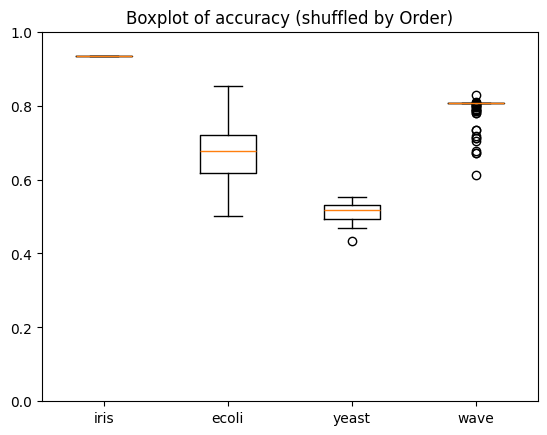

In [27]:
iris_acc = []
ecoli_acc = []
wave_acc = []
yeast_acc = []

for _, result in iris_result.items():
    iris_acc.append(result["acc"])
for _, result in ecoli_result.items():
    ecoli_acc.append(result["acc"])
for _, result in yeast_result.items():
    yeast_acc.append(result["acc"])
for _, result in wave_result.items():
    wave_acc.append(result["acc"])

plt.boxplot([iris_acc, ecoli_acc, yeast_acc, wave_acc])
plt.xticks([1, 2, 3, 4], ["iris", "ecoli", "yeast", "wave"])
plt.ylim(0, 1)
plt.title("Boxplot of accuracy (shuffled by Order)")
plt.show()